# Section 23: Generative adversarial networks

In [1]:
import numpy as np

import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Subset, DataLoader

import torchvision
import torchvision.transforms as T

## Linear GAN with MNIST

In [2]:
device = torch.device('mps' if torch.mps.is_available() else 'cpu')

In [3]:
data = np.loadtxt(open('mnist_train_small.csv', 'rb'), delimiter=',')

data = data[:, 1:]
data_norm = data / np.max(data)
data_norm = 2 * data_norm - 1

data_t = torch.tensor(data_norm).float()
batch_size = 100

In [4]:
class DisNet(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.fc1 = nn.Linear(28 * 28, 256)
        self.fc2 = nn.Linear(256, 256)
        self.out = nn.Linear(256, 1)
        
    def forward(self, x_param):
        x_local = F.leaky_relu(self.fc1(x_param))
        x_local = F.leaky_relu(self.fc2(x_local))
        x_local = torch.sigmoid(self.out(x_local))
        
        return x_local
    
dis_net = DisNet()
y_pred = dis_net(torch.randn(10, 784))

y_pred

tensor([[0.5014],
        [0.4372],
        [0.4787],
        [0.4997],
        [0.4677],
        [0.4715],
        [0.5198],
        [0.4874],
        [0.4622],
        [0.4860]], grad_fn=<SigmoidBackward0>)

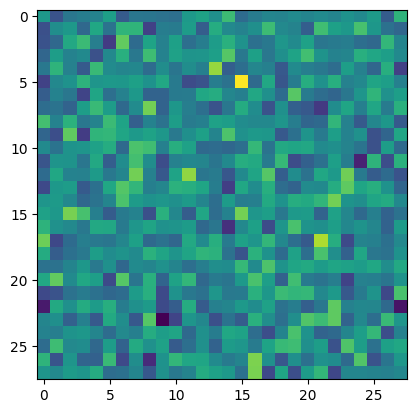

In [5]:
class GenNet(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.fc1 = nn.Linear(64, 256)
        self.fc2 = nn.Linear(256, 256)
        self.out = nn.Linear(256, 784)
        
    def forward(self, x_param):
        x_local = F.leaky_relu(self.fc1(x_param))
        x_local = F.leaky_relu(self.fc2(x_local))
        x_local = torch.tanh(self.out(x_local))
        
        return x_local
    
gen_net = GenNet()
y_pred = gen_net(torch.randn(10, 64))

plt.imshow(y_pred[0, :].detach().squeeze().view(28, 28))
plt.show()

In [6]:
loss_function = nn.BCELoss()

dis_net = DisNet().to(device)
gen_net = GenNet().to(device)

dis_optimizer = torch.optim.Adam(dis_net.parameters(), lr=.0003)
gen_optimizer = torch.optim.Adam(gen_net.parameters(), lr=.0003)

In [7]:
epochs_nr = 50000

losses = np.zeros((epochs_nr, 2))
dis_decisions = np.zeros((epochs_nr, 2))
real_labels = torch.ones(batch_size, 1).to(device)
fake_labels = torch.zeros(batch_size, 1).to(device)

for epoch in range(epochs_nr):
    random_index = torch.randint(data_t.shape[0], (batch_size,))
    real_images = data_t[random_index, :].to(device)
    fake_images = gen_net(torch.randn(batch_size, 64).to(device))
    
    # Train the discriminator
    real_pred = dis_net(real_images)
    real_loss = loss_function(real_pred, real_labels)
    
    fake_pred = dis_net(fake_images)
    fake_loss = loss_function(fake_pred, fake_labels)
    
    dis_loss = real_loss + fake_loss
    losses[epoch, 0] = dis_loss.item()
    dis_decisions[epoch, 0] = torch.mean((real_pred > .5).float()).detach()
    
    dis_optimizer.zero_grad()
    dis_loss.backward()
    dis_optimizer.step()

    # Train the generator
    fake_images = gen_net(torch.randn(batch_size, 64).to(device))
    fake_pred = dis_net(fake_images)
    
    gen_loss = loss_function(fake_pred, real_labels)
    losses[epoch, 1] = gen_loss.item()
    dis_decisions[epoch, 1] = torch.mean((fake_pred > .5).float()).detach()
    
    gen_optimizer.zero_grad()
    gen_loss.backward()
    gen_optimizer.step()

    if (epoch + 1) % 5000 == 0:
        print(f"Finished epochs {epoch + 1}/{epochs_nr}")

Finished epochs 5000/50000
Finished epochs 10000/50000
Finished epochs 15000/50000
Finished epochs 20000/50000
Finished epochs 25000/50000
Finished epochs 30000/50000
Finished epochs 35000/50000
Finished epochs 40000/50000
Finished epochs 45000/50000
Finished epochs 50000/50000


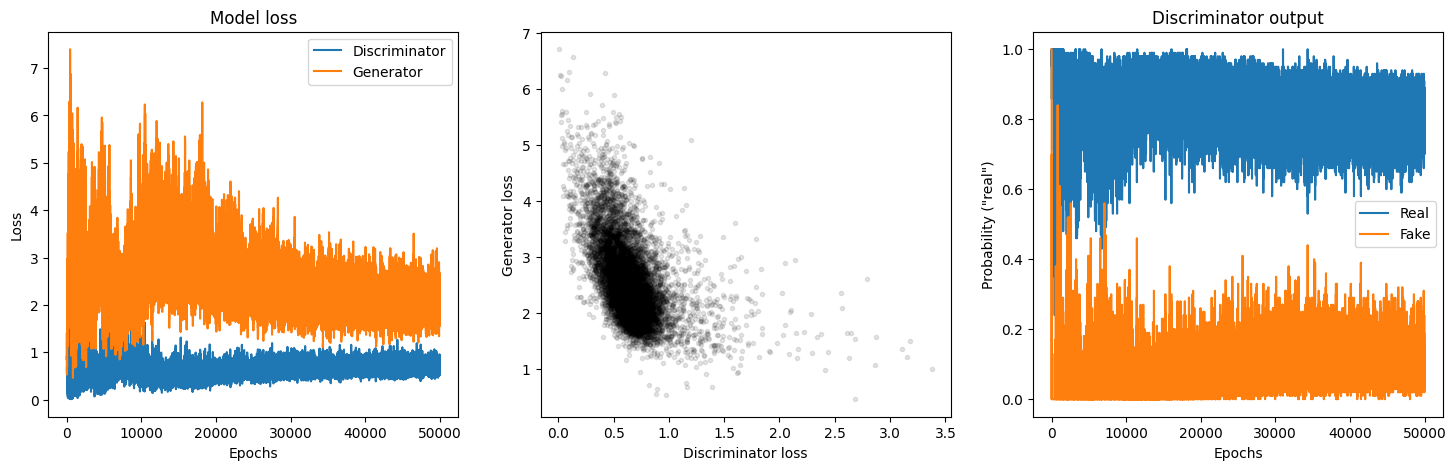

In [8]:
_, ax = plt.subplots(1, 3, figsize=(18, 5))

ax[0].plot(losses)
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Loss')
ax[0].set_title("Model loss")
ax[0].legend(['Discriminator', 'Generator'])

ax[1].plot(losses[::5, 0], losses[::5, 1], 'k.', alpha=.1)
ax[1].set_xlabel("Discriminator loss")
ax[1].set_ylabel("Generator loss")

ax[2].plot(dis_decisions)
ax[2].set_xlabel('Epochs')
ax[2].set_ylabel("Probability (\"real\")")
ax[2].set_title("Discriminator output")
ax[2].legend(['Real', 'Fake'])

plt.show()

In [9]:
gen_net.eval()

fake_images = torch.randn(12, 64).to(device)
generated_images = gen_net(fake_images).cpu()

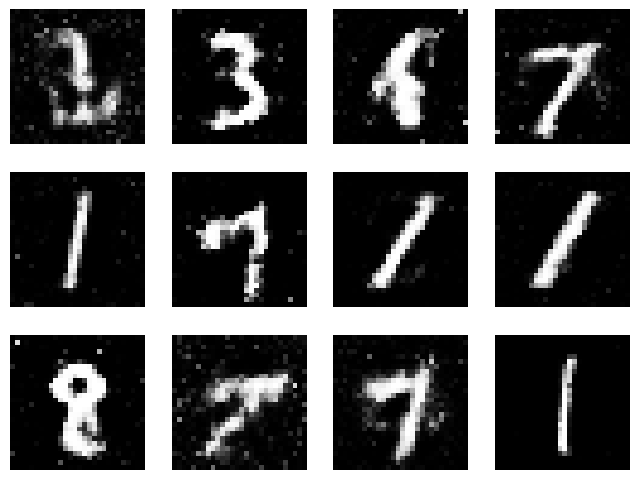

In [10]:
_, axs = plt.subplots(3, 4, figsize=(8, 6))

for i, ax in enumerate(axs.flatten()):
    ax.imshow(generated_images[i, :].detach().view(28, 28), cmap='gray')
    ax.axis('off')

plt.show()

## CodeChallenge: Linear GAN with FMNIST

In [11]:
transform = T.Compose([
    T.ToTensor(),
    T.Normalize(.5, .5),
    T.Lambda(torch.flatten)
])
fmnist = torchvision.datasets.FashionMNIST(root='./fmnist', download=True, transform=transform)

selected_classes = ['Trouser', 'Sneaker', 'Pullover']
selected_class_indexes = [fmnist.classes.index(selected_class) for selected_class in selected_classes]

mask = torch.isin(fmnist.targets, torch.tensor(selected_class_indexes))
fmnist_subset = Subset(fmnist, torch.where(mask)[0].tolist())

loader = DataLoader(fmnist_subset, batch_size=batch_size, shuffle=True, drop_last=True)

In [12]:
loss_function = nn.BCELoss()

dis_net = DisNet().to(device)
gen_net = GenNet().to(device)

dis_optimizer = torch.optim.Adam(dis_net.parameters(), lr=.0003)
gen_optimizer = torch.optim.Adam(gen_net.parameters(), lr=.0003)

In [13]:
original_epochs_nr = 10000
epochs_nr = int(original_epochs_nr / len(loader))

losses = np.zeros((epochs_nr, 2))
dis_decisions = np.zeros((epochs_nr, 2))
real_labels = torch.ones(batch_size, 1).to(device)
fake_labels = torch.zeros(batch_size, 1).to(device)

for epoch in range(epochs_nr):
    batch_losses = np.zeros((len(loader), 2))
    batch_decisions = np.zeros((len(loader), 2))

    for batch_index, (X, _) in enumerate(loader):
        real_images = X.to(device)
        fake_images = gen_net(torch.randn(batch_size, 64).to(device))

        # Train the discriminator
        real_pred = dis_net(real_images)
        real_loss = loss_function(real_pred, real_labels)

        fake_pred = dis_net(fake_images)
        fake_loss = loss_function(fake_pred, fake_labels)

        dis_loss = real_loss + fake_loss
        batch_losses[batch_index, 0] = dis_loss.item()
        batch_decisions[batch_index, 0] = torch.mean((real_pred > .5).float()).item()

        dis_optimizer.zero_grad()
        dis_loss.backward()
        dis_optimizer.step()

        # Train the generator
        fake_images = gen_net(torch.randn(batch_size, 64).to(device))
        fake_pred = dis_net(fake_images)

        gen_loss = loss_function(fake_pred, real_labels)
        batch_losses[batch_index, 1] = gen_loss.item()
        batch_decisions[batch_index, 1] = torch.mean((fake_pred > .5).float()).item()

        gen_optimizer.zero_grad()
        gen_loss.backward()
        gen_optimizer.step()

    losses[epoch, :] = np.mean(batch_losses, axis=0)
    dis_decisions[epoch, :] = np.mean(batch_decisions, axis=0)

    if (epoch + 1) % 5 == 0:
        print(f"Finished epochs {epoch + 1}/{epochs_nr}")

Finished epochs 5/55
Finished epochs 10/55
Finished epochs 15/55
Finished epochs 20/55
Finished epochs 25/55
Finished epochs 30/55
Finished epochs 35/55
Finished epochs 40/55
Finished epochs 45/55
Finished epochs 50/55
Finished epochs 55/55


In [14]:
def smooth(x_param, k=15):
  return np.convolve(x_param, np.ones(k) / k, mode='same')

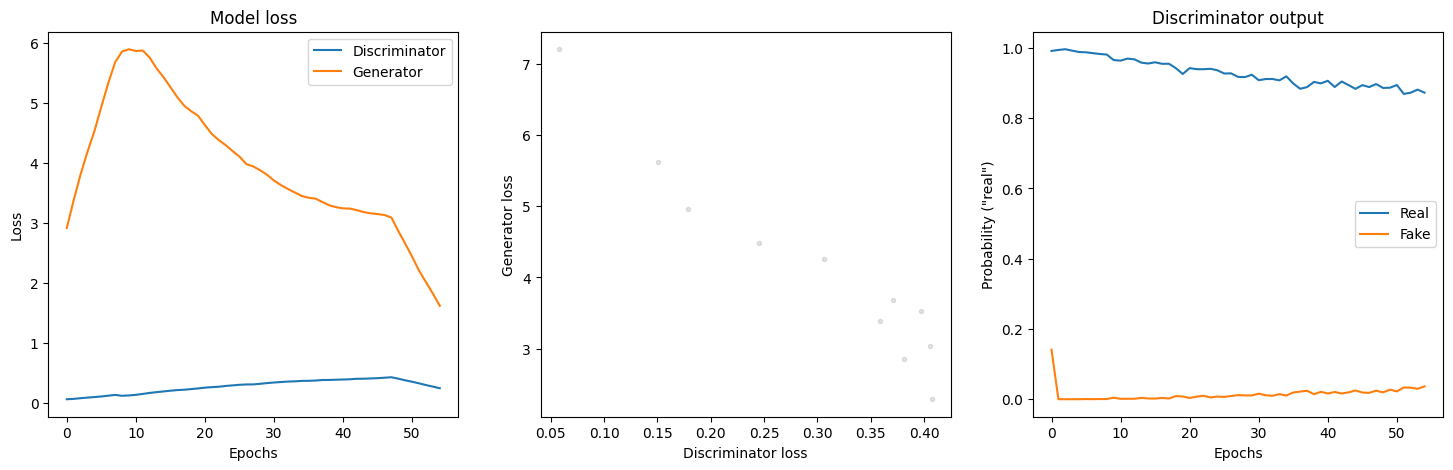

In [15]:
_, ax = plt.subplots(1, 3, figsize=(18, 5))

ax[0].plot(smooth(losses[:, 0]))
ax[0].plot(smooth(losses[:, 1]))
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Loss')
ax[0].set_title("Model loss")
ax[0].legend(['Discriminator', 'Generator'])

ax[1].plot(losses[::5, 0], losses[::5, 1], 'k.', alpha=.1)
ax[1].set_xlabel("Discriminator loss")
ax[1].set_ylabel("Generator loss")

ax[2].plot(dis_decisions)
ax[2].set_xlabel('Epochs')
ax[2].set_ylabel("Probability (\"real\")")
ax[2].set_title("Discriminator output")
ax[2].legend(['Real', 'Fake'])

plt.show()

In [16]:
gen_net.eval()

fake_images = torch.randn(12, 64).to(device)
generated_images = gen_net(fake_images).cpu()

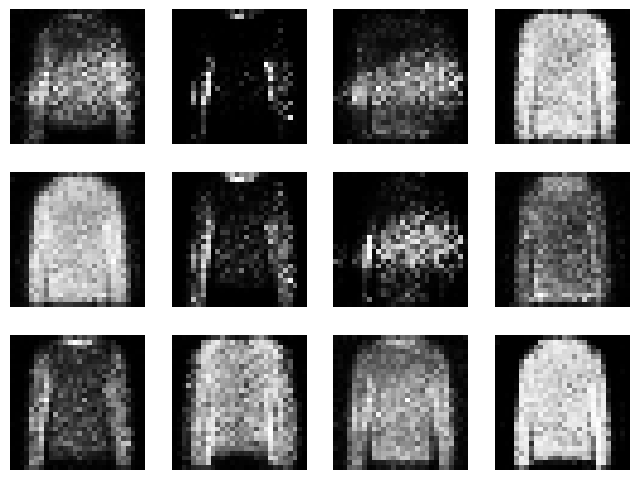

In [17]:
_, axs = plt.subplots(3, 4, figsize=(8, 6))

for i, ax in enumerate(axs.flatten()):
    ax.imshow(generated_images[i, :].detach().view(28, 28), cmap='gray')
    ax.axis('off')

plt.show()

## CNN GAN with Gaussians

In [18]:
samples_per_class = 3000
image_size = 64
x = np.linspace(-4, 4, image_size)
X, Y = np.meshgrid(x, x)

images = torch.zeros(2 * samples_per_class, 1, image_size, image_size)

for i in range(2 * samples_per_class):
    random_offset = 2 * np.random.randn(2)
    width = np.random.rand() / .6 + 1.8
    gaussian = np.exp(-((X - random_offset[0]) ** 2 + (Y - random_offset[1]) ** 2) / ( 2 * width ** 2))
    gaussian = gaussian + np.random.randn(image_size, image_size) / 5
    
    images[i, :, :, :] = torch.Tensor(gaussian).view(1, image_size, image_size)

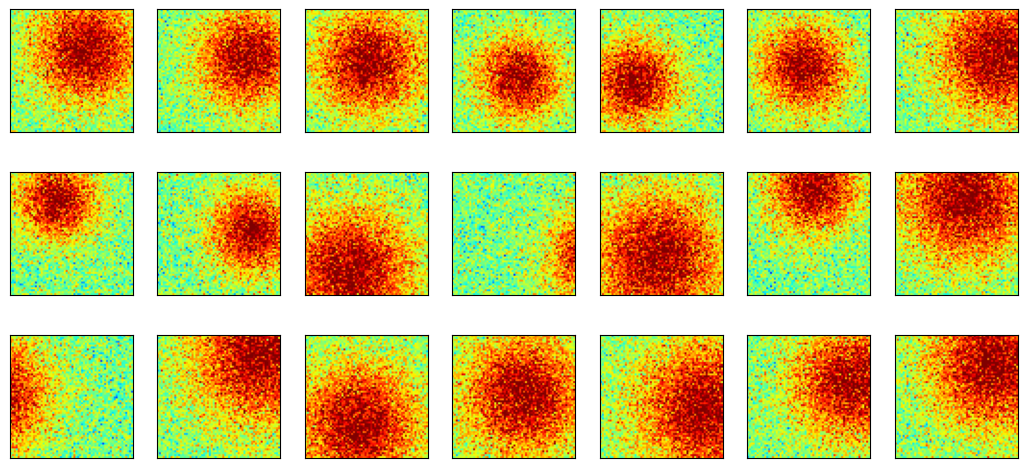

In [19]:
_, ax = plt.subplots(3, 7, figsize=(13, 6))

for i, ax in enumerate(ax.flatten()):
    index = np.random.randint(2 * samples_per_class)
    gaussian = np.squeeze(images[index, :, :])
    
    ax.imshow(gaussian, vmin=-1, vmax=1, cmap='jet')
    ax.set_xticks([])
    ax.set_yticks([])
    
plt.show()

In [20]:
class DisNet(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.conv1 = nn.Conv2d(1, 64, 4, 2, 1, bias=False)
        self.conv2 = nn.Conv2d(64, 128, 4, 2, 1, bias=False)
        self.conv3 = nn.Conv2d(128, 256, 4, 2, 1, bias=False)
        self.conv4 = nn.Conv2d(256, 512, 4, 2, 1, bias=False)
        self.conv5 = nn.Conv2d(512, 1, 4, 1, 0, bias=False)
        
        self.bnorm2 = nn.BatchNorm2d(128)
        self.bnorm3 = nn.BatchNorm2d(256)
        self.bnorm4 = nn.BatchNorm2d(512)
        
    def forward(self, x_param):
        x_local = F.leaky_relu(self.conv1(x_param), .2)
        x_local = self.bnorm2(F.leaky_relu(self.conv2(x_local), .2))
        x_local = self.bnorm3(F.leaky_relu(self.conv3(x_local), .2))
        x_local = self.bnorm4(F.leaky_relu(self.conv4(x_local), .2))
        x_local = torch.sigmoid(self.conv5(x_local)).view(-1, 1)
        
        return x_local
    
    
dis_net = DisNet()
y_pred = dis_net(torch.randn(10, 1, 64, 64))

y_pred

tensor([[0.6220],
        [0.6368],
        [0.5861],
        [0.6745],
        [0.3838],
        [0.5755],
        [0.2181],
        [0.5920],
        [0.5656],
        [0.4439]], grad_fn=<ViewBackward0>)

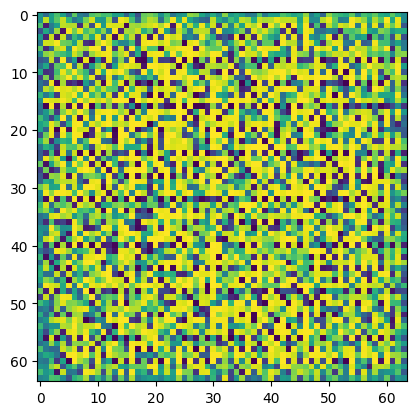

In [21]:
class GenNet(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.conv1 = nn.ConvTranspose2d(100, 512, 4, 1, 0, bias=False)
        self.conv2 = nn.ConvTranspose2d(512, 256, 4, 2, 1, bias=False)
        self.conv3 = nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False)
        self.conv4 = nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False)
        self.conv5 = nn.ConvTranspose2d(64, 1, 4, 2, 1, bias=False)
        
        self.bnorm1 = nn.BatchNorm2d(512)
        self.bnorm2 = nn.BatchNorm2d(256)
        self.bnorm3 = nn.BatchNorm2d(128)
        self.bnorm4 = nn.BatchNorm2d(64)
        
    def forward(self, x_param):
        x_local = F.relu(self.bnorm1(self.conv1(x_param)))
        x_local = F.relu(self.bnorm2(self.conv2(x_local)))
        x_local = F.relu(self.bnorm3(self.conv3(x_local)))
        x_local = F.relu(self.bnorm4(self.conv4(x_local)))
        x_local = torch.tanh(self.conv5(x_local))
        
        return x_local
    
gen_net = GenNet()
y_pred = gen_net(torch.randn(10, 100, 1, 1))

plt.imshow(y_pred[0, :].detach().squeeze().numpy())
plt.show()

In [22]:
loss_function = nn.BCELoss()

dis_net = DisNet().to(device)
gen_net = GenNet().to(device)

dis_optimizer = torch.optim.Adam(dis_net.parameters(), lr=.0002, betas=(.5, .999))
gen_optimizer = torch.optim.Adam(gen_net.parameters(), lr=.0002, betas=(.5, .999))

In [23]:
epochs_nr = 500
batch_size = 86

losses = np.zeros((epochs_nr, 2))
dis_decisions = np.zeros((epochs_nr, 2))
real_labels = torch.ones(batch_size, 1).to(device)
fake_labels = torch.zeros(batch_size, 1).to(device)

for epoch in range(epochs_nr):
    random_index = torch.randint(images.shape[0], (batch_size,))
    real_images = images[random_index, :].to(device)
    fake_images = gen_net(torch.randn(batch_size, 100, 1, 1).to(device))
    
    # Train the discriminator
    real_pred = dis_net(real_images)
    real_loss = loss_function(real_pred, real_labels)
    
    fake_pred = dis_net(fake_images)
    fake_loss = loss_function(fake_pred, fake_labels)
    
    dis_loss = real_loss + fake_loss
    losses[epoch, 0] = dis_loss.item()
    dis_decisions[epoch, 0] = torch.mean((real_pred > .5).float()).detach()
    
    dis_optimizer.zero_grad()
    dis_loss.backward()
    dis_optimizer.step()

    # Train the generator
    fake_images = gen_net(torch.randn(batch_size, 100, 1, 1).to(device))
    fake_pred = dis_net(fake_images)
    
    gen_loss = loss_function(fake_pred, real_labels)
    losses[epoch, 1] = gen_loss.item()
    dis_decisions[epoch, 1] = torch.mean((fake_pred > .5).float()).detach()
    
    gen_optimizer.zero_grad()
    gen_loss.backward()
    gen_optimizer.step()

    if (epoch + 1) % 100 == 0:
        print(f"Finished epochs {epoch + 1}/{epochs_nr}")

Finished epochs 100/500
Finished epochs 200/500
Finished epochs 300/500
Finished epochs 400/500
Finished epochs 500/500


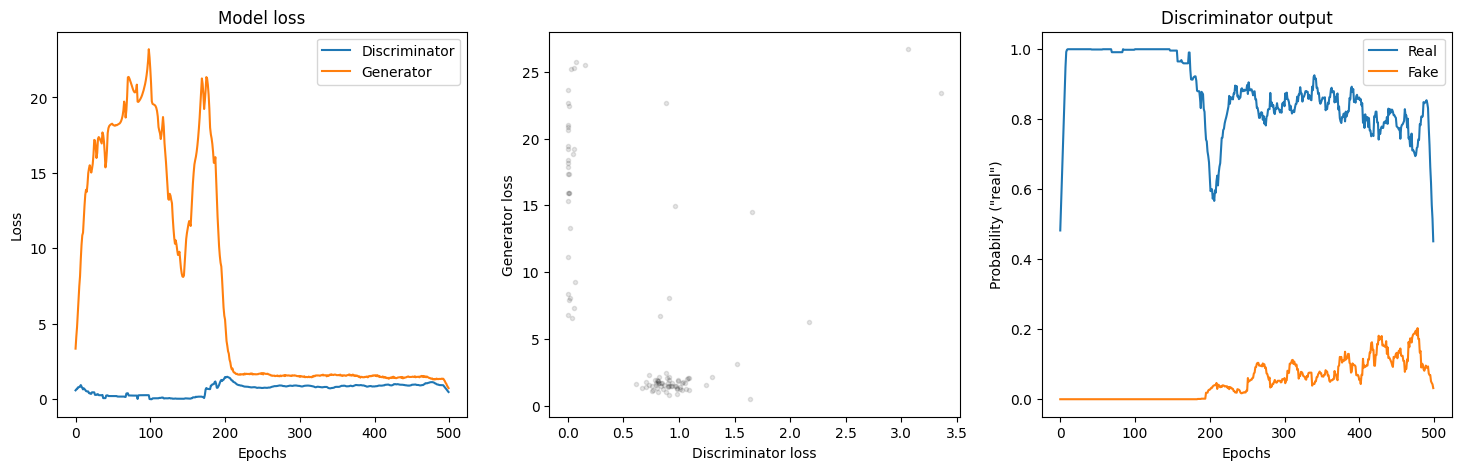

In [24]:
_, ax = plt.subplots(1, 3, figsize=(18, 5))

ax[0].plot(smooth(losses[:, 0]))
ax[0].plot(smooth(losses[:, 1]))
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Loss')
ax[0].set_title("Model loss")
ax[0].legend(['Discriminator', 'Generator'])

ax[1].plot(losses[::5, 0], losses[::5, 1], 'k.', alpha=.1)
ax[1].set_xlabel("Discriminator loss")
ax[1].set_ylabel("Generator loss")

ax[2].plot(smooth(dis_decisions[:, 0]))
ax[2].plot(smooth(dis_decisions[:, 1]))
ax[2].set_xlabel('Epochs')
ax[2].set_ylabel("Probability (\"real\")")
ax[2].set_title("Discriminator output")
ax[2].legend(['Real', 'Fake'])

plt.show()

In [25]:
gen_net.eval()

fake_images = torch.randn(12, 100, 1, 1).to(device)
generated_images = gen_net(fake_images).cpu()

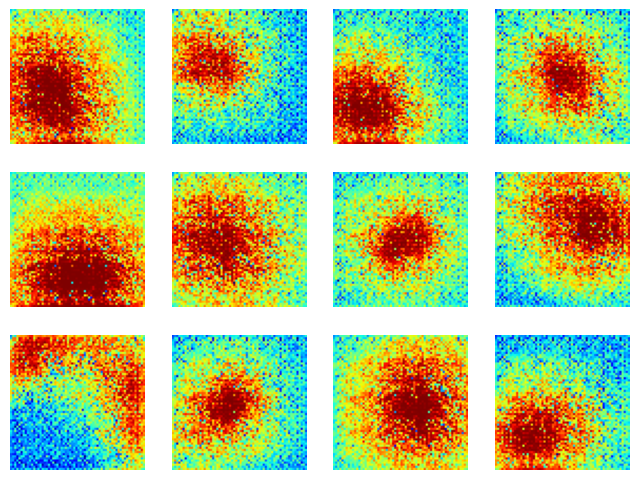

In [26]:
_, axs = plt.subplots(3, 4, figsize=(8, 6))

for i, ax in enumerate(axs.flatten()):
    ax.imshow(generated_images[i, :].detach().view(64, 64), cmap='jet')
    ax.axis('off')

plt.show()

## CodeChallenge: Gaussians with fewer layers

In [27]:
class DisNet(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.conv1 = nn.Conv2d(1, 64, 4, 3, 0, bias=False)
        self.conv2 = nn.Conv2d(64, 128, 4, 3, 0, bias=False)
        self.conv3 = nn.Conv2d(128, 1, 4, 3, 0, bias=False)
        
        self.bnorm2 = nn.BatchNorm2d(128)
        
    def forward(self, x_param):
        x_local = F.leaky_relu(self.conv1(x_param), .2)
        x_local = self.bnorm2(F.leaky_relu(self.conv2(x_local), .2))
        x_local = torch.sigmoid(self.conv3(x_local)).view(-1, 1)

        return x_local
    
    
dis_net = DisNet()
y_pred = dis_net(torch.randn(10, 1, 64, 64))

y_pred

tensor([[0.6207],
        [0.6583],
        [0.4075],
        [0.6832],
        [0.4232],
        [0.5153],
        [0.7027],
        [0.5259],
        [0.4465],
        [0.2912]], grad_fn=<ViewBackward0>)

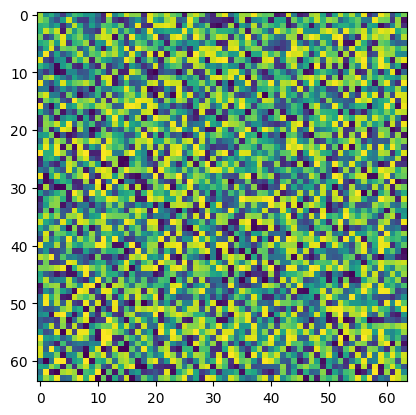

In [28]:
class GenNet(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.conv1 = nn.ConvTranspose2d(100, 256, 4, 4, 0, bias=False)
        self.conv2 = nn.ConvTranspose2d(256, 128, 4, 4, 0, bias=False)
        self.conv3 = nn.ConvTranspose2d(128, 1, 4, 4, 0, bias=False)
        
        self.bnorm1 = nn.BatchNorm2d(256)
        self.bnorm2 = nn.BatchNorm2d(128)
        
    def forward(self, x_param):
        x_local = F.relu(self.bnorm1(self.conv1(x_param)))
        x_local = F.relu(self.bnorm2(self.conv2(x_local)))
        x_local = torch.tanh(self.conv3(x_local))
        
        return x_local
    
gen_net = GenNet()
y_pred = gen_net(torch.randn(10, 100, 1, 1))

plt.imshow(y_pred[0, :].detach().squeeze().numpy())
plt.show()

In [29]:
loss_function = nn.BCELoss()

dis_net = DisNet().to(device)
gen_net = GenNet().to(device)

dis_optimizer = torch.optim.Adam(dis_net.parameters(), lr=.0002, betas=(.5, .999))
gen_optimizer = torch.optim.Adam(gen_net.parameters(), lr=.0002, betas=(.5, .999))

In [30]:
epochs_nr = 500
batch_size = 86

losses = np.zeros((epochs_nr, 2))
dis_decisions = np.zeros((epochs_nr, 2))
real_labels = torch.ones(batch_size, 1).to(device)
fake_labels = torch.zeros(batch_size, 1).to(device)

for epoch in range(epochs_nr):
    random_index = torch.randint(images.shape[0], (batch_size,))
    real_images = images[random_index, :].to(device)
    fake_images = gen_net(torch.randn(batch_size, 100, 1, 1).to(device))
    
    # Train the discriminator
    real_pred = dis_net(real_images)
    real_loss = loss_function(real_pred, real_labels)
    
    fake_pred = dis_net(fake_images)
    fake_loss = loss_function(fake_pred, fake_labels)
    
    dis_loss = real_loss + fake_loss
    losses[epoch, 0] = dis_loss.item()
    dis_decisions[epoch, 0] = torch.mean((real_pred > .5).float()).detach()
    
    dis_optimizer.zero_grad()
    dis_loss.backward()
    dis_optimizer.step()

    # Train the generator
    fake_images = gen_net(torch.randn(batch_size, 100, 1, 1).to(device))
    fake_pred = dis_net(fake_images)
    
    gen_loss = loss_function(fake_pred, real_labels)
    losses[epoch, 1] = gen_loss.item()
    dis_decisions[epoch, 1] = torch.mean((fake_pred > .5).float()).detach()
    
    gen_optimizer.zero_grad()
    gen_loss.backward()
    gen_optimizer.step()

    if (epoch + 1) % 100 == 0:
        print(f"Finished epochs {epoch + 1}/{epochs_nr}")

Finished epochs 100/500
Finished epochs 200/500
Finished epochs 300/500
Finished epochs 400/500
Finished epochs 500/500


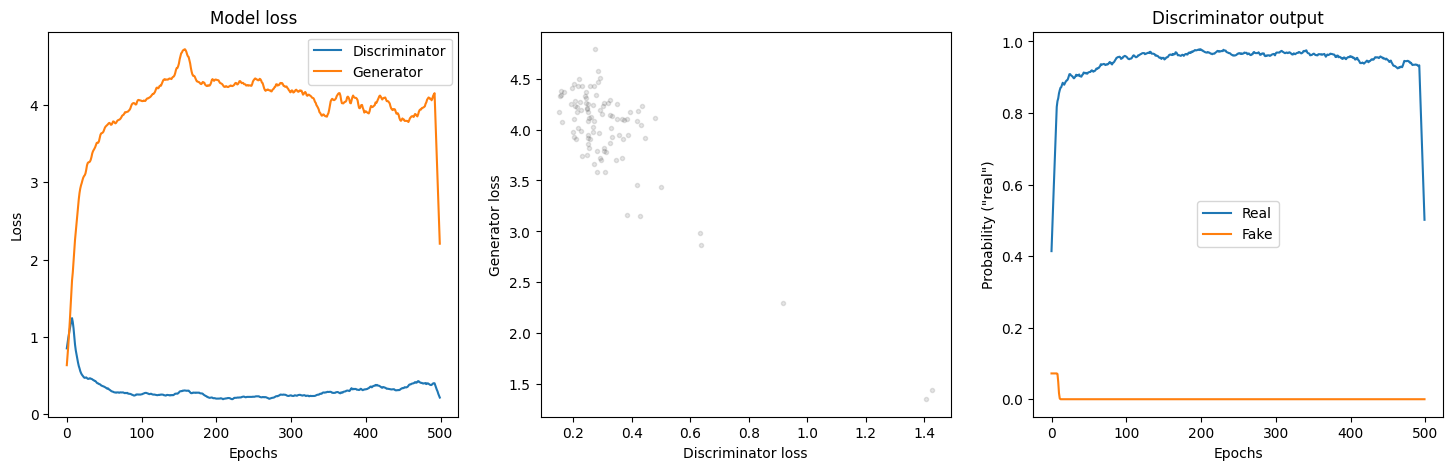

In [31]:
_, ax = plt.subplots(1, 3, figsize=(18, 5))

ax[0].plot(smooth(losses[:, 0]))
ax[0].plot(smooth(losses[:, 1]))
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Loss')
ax[0].set_title("Model loss")
ax[0].legend(['Discriminator', 'Generator'])

ax[1].plot(losses[::5, 0], losses[::5, 1], 'k.', alpha=.1)
ax[1].set_xlabel("Discriminator loss")
ax[1].set_ylabel("Generator loss")

ax[2].plot(smooth(dis_decisions[:, 0]))
ax[2].plot(smooth(dis_decisions[:, 1]))
ax[2].set_xlabel('Epochs')
ax[2].set_ylabel("Probability (\"real\")")
ax[2].set_title("Discriminator output")
ax[2].legend(['Real', 'Fake'])

plt.show()

In [32]:
gen_net.eval()

fake_images = torch.randn(12, 100, 1, 1).to(device)
generated_images = gen_net(fake_images).cpu()

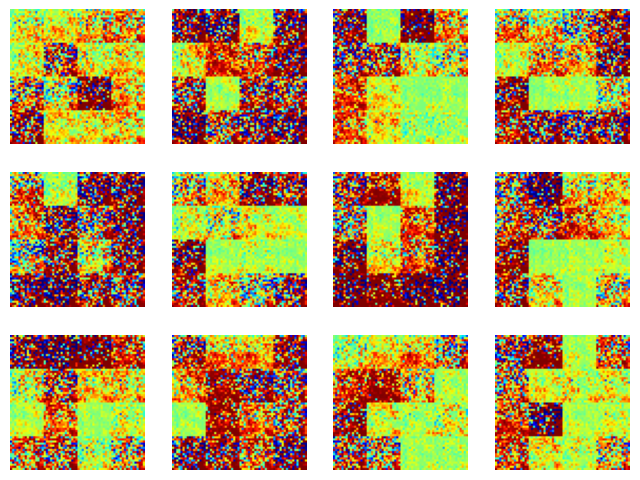

In [33]:
_, axs = plt.subplots(3, 4, figsize=(8, 6))

for i, ax in enumerate(axs.flatten()):
    ax.imshow(generated_images[i, :].detach().view(64, 64), cmap='jet')
    ax.axis('off')

plt.show()

## CNN GAN with FMNIST

In [34]:
class DisNet(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.conv1 = nn.Conv2d(1, 64, 4, 2, 1, bias=False)
        self.conv2 = nn.Conv2d(64, 128, 4, 2, 1, bias=False)
        self.conv3 = nn.Conv2d(128, 256, 4, 2, 1, bias=False)
        self.conv4 = nn.Conv2d(256, 512, 4, 2, 1, bias=False)
        self.conv5 = nn.Conv2d(512, 1, 4, 1, 0, bias=False)
        
        self.bnorm2 = nn.BatchNorm2d(128)
        self.bnorm3 = nn.BatchNorm2d(256)
        self.bnorm4 = nn.BatchNorm2d(512)
        
    def forward(self, x_param):
        x_local = F.leaky_relu(self.conv1(x_param), .2)
        x_local = self.bnorm2(F.leaky_relu(self.conv2(x_local), .2))
        x_local = self.bnorm3(F.leaky_relu(self.conv3(x_local), .2))
        x_local = self.bnorm4(F.leaky_relu(self.conv4(x_local), .2))
        x_local = torch.sigmoid(self.conv5(x_local)).view(-1, 1)
        
        return x_local
    
    
dis_net = DisNet()
y_pred = dis_net(torch.randn(10, 1, 64, 64))

y_pred

tensor([[0.5155],
        [0.4488],
        [0.3160],
        [0.4562],
        [0.4524],
        [0.3097],
        [0.4566],
        [0.6797],
        [0.3999],
        [0.3166]], grad_fn=<ViewBackward0>)

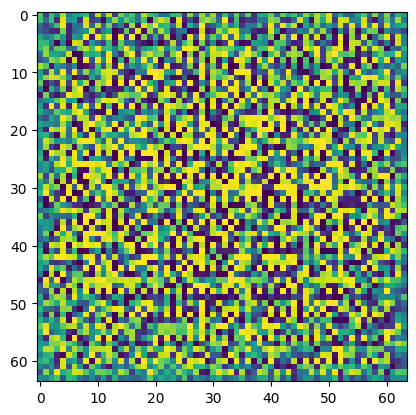

In [35]:
class GenNet(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.conv1 = nn.ConvTranspose2d(100, 512, 4, 1, 0, bias=False)
        self.conv2 = nn.ConvTranspose2d(512, 256, 4, 2, 1, bias=False)
        self.conv3 = nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False)
        self.conv4 = nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False)
        self.conv5 = nn.ConvTranspose2d(64, 1, 4, 2, 1, bias=False)
        
        self.bnorm1 = nn.BatchNorm2d(512)
        self.bnorm2 = nn.BatchNorm2d(256)
        self.bnorm3 = nn.BatchNorm2d(128)
        self.bnorm4 = nn.BatchNorm2d(64)
        
    def forward(self, x_param):
        x_local = F.relu(self.bnorm1(self.conv1(x_param)))
        x_local = F.relu(self.bnorm2(self.conv2(x_local)))
        x_local = F.relu(self.bnorm3(self.conv3(x_local)))
        x_local = F.relu(self.bnorm4(self.conv4(x_local)))
        x_local = torch.tanh(self.conv5(x_local))
        
        return x_local
    
gen_net = GenNet()
y_pred = gen_net(torch.randn(10, 100, 1, 1))

plt.imshow(y_pred[0, :].detach().squeeze().numpy())
plt.show()

In [36]:
transform = T.Compose([
    T.ToTensor(),
    T.Resize(64),
    T.Normalize(.5, .5),
])
fmnist = torchvision.datasets.FashionMNIST(root='./fmnist', download=True, transform=transform)

selected_classes = ['Trouser', 'Sneaker', 'Pullover']
selected_class_indexes = [fmnist.classes.index(selected_class) for selected_class in selected_classes]

mask = torch.isin(fmnist.targets, torch.tensor(selected_class_indexes))
fmnist_subset = Subset(fmnist, torch.where(mask)[0].tolist())

batch_size = 100
loader = DataLoader(fmnist_subset, batch_size=batch_size, shuffle=True, drop_last=True)

In [37]:
loss_function = nn.BCELoss()

dis_net = DisNet().to(device)
gen_net = GenNet().to(device)

dis_optimizer = torch.optim.Adam(dis_net.parameters(), lr=.0002, betas=(.5, .999))
gen_optimizer = torch.optim.Adam(gen_net.parameters(), lr=.0002, betas=(.5, .999))

In [38]:
original_epochs_nr = 2500
epochs_nr = int(original_epochs_nr / len(loader))

losses = np.zeros((epochs_nr, 2))
dis_decisions = np.zeros((epochs_nr, 2))
real_labels = torch.ones(batch_size, 1).to(device)
fake_labels = torch.zeros(batch_size, 1).to(device)

for epoch in range(epochs_nr):
    batch_losses = np.zeros((len(loader), 2))
    batch_decisions = np.zeros((len(loader), 2))

    for batch_index, (X, _) in enumerate(loader):
        real_images = X.to(device)
        fake_images = gen_net(torch.randn(batch_size, 100, 1, 1).to(device))

        # Train the discriminator
        real_pred = dis_net(real_images)
        real_loss = loss_function(real_pred, real_labels)

        fake_pred = dis_net(fake_images)
        fake_loss = loss_function(fake_pred, fake_labels)

        dis_loss = real_loss + fake_loss
        batch_losses[batch_index, 0] = dis_loss.item()
        batch_decisions[batch_index, 0] = torch.mean((real_pred > .5).float()).item()

        dis_optimizer.zero_grad()
        dis_loss.backward()
        dis_optimizer.step()

        # Train the generator
        fake_images = gen_net(torch.randn(batch_size, 100, 1, 1).to(device))
        fake_pred = dis_net(fake_images)

        gen_loss = loss_function(fake_pred, real_labels)
        batch_losses[batch_index, 1] = gen_loss.item()
        batch_decisions[batch_index, 1] = torch.mean((fake_pred > .5).float()).item()

        gen_optimizer.zero_grad()
        gen_loss.backward()
        gen_optimizer.step()

    losses[epoch, :] = np.mean(batch_losses, axis=0)
    dis_decisions[epoch, :] = np.mean(batch_decisions, axis=0)

    if (epoch + 1) % 13 == 0:
        print(f"Finished epochs {epoch + 1}/{epochs_nr}")

Finished epochs 13/13


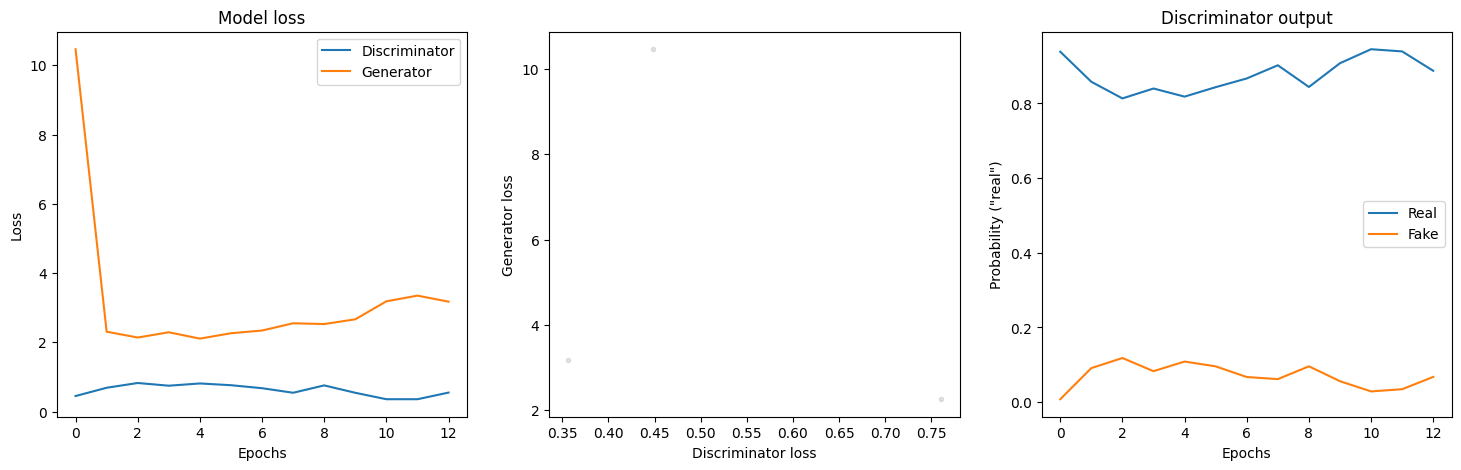

In [39]:
_, ax = plt.subplots(1, 3, figsize=(18, 5))

ax[0].plot(losses[:, 0])
ax[0].plot(losses[:, 1])
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Loss')
ax[0].set_title("Model loss")
ax[0].legend(['Discriminator', 'Generator'])

ax[1].plot(losses[::5, 0], losses[::5, 1], 'k.', alpha=.1)
ax[1].set_xlabel("Discriminator loss")
ax[1].set_ylabel("Generator loss")

ax[2].plot(dis_decisions[:, 0])
ax[2].plot(dis_decisions[:, 1])
ax[2].set_xlabel('Epochs')
ax[2].set_ylabel("Probability (\"real\")")
ax[2].set_title("Discriminator output")
ax[2].legend(['Real', 'Fake'])

plt.show()

In [40]:
gen_net.eval()

fake_images = torch.randn(12, 100, 1, 1).to(device)
generated_images = gen_net(fake_images).cpu()

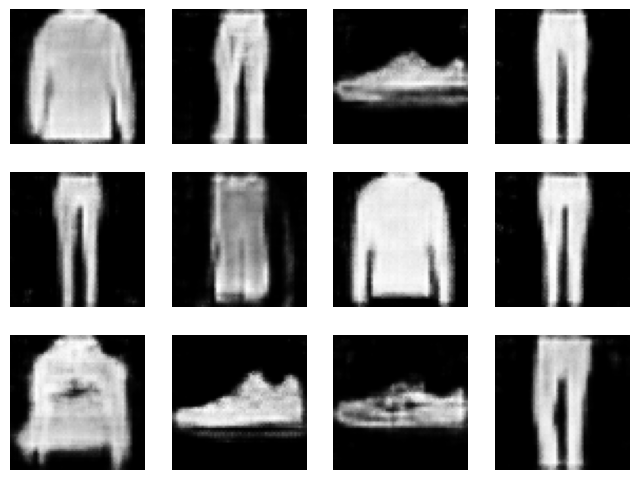

In [41]:
_, axs = plt.subplots(3, 4, figsize=(8, 6))

for i, ax in enumerate(axs.flatten()):
    ax.imshow(generated_images[i, :].detach().view(64, 64), cmap='gray')
    ax.axis('off')

plt.show()

## CodeChallenge: CNN GAN with CIFAR

In [42]:
class DisNet(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.conv1 = nn.Conv2d(3, 64, 4, 2, 1, bias=False)
        self.conv2 = nn.Conv2d(64, 128, 4, 2, 1, bias=False)
        self.conv3 = nn.Conv2d(128, 256, 4, 2, 1, bias=False)
        self.conv4 = nn.Conv2d(256, 512, 4, 2, 1, bias=False)
        self.conv5 = nn.Conv2d(512, 1, 4, 1, 0, bias=False)
        
        self.bnorm2 = nn.BatchNorm2d(128)
        self.bnorm3 = nn.BatchNorm2d(256)
        self.bnorm4 = nn.BatchNorm2d(512)
        
    def forward(self, x_param):
        x_local = F.leaky_relu(self.conv1(x_param), .2)
        x_local = self.bnorm2(F.leaky_relu(self.conv2(x_local), .2))
        x_local = self.bnorm3(F.leaky_relu(self.conv3(x_local), .2))
        x_local = self.bnorm4(F.leaky_relu(self.conv4(x_local), .2))
        x_local = torch.sigmoid(self.conv5(x_local)).view(-1, 1)
        
        return x_local
    
    
dis_net = DisNet()
y_pred = dis_net(torch.randn(10, 3, 64, 64))

y_pred

tensor([[0.1995],
        [0.4629],
        [0.3056],
        [0.2396],
        [0.3958],
        [0.6398],
        [0.4271],
        [0.4207],
        [0.5703],
        [0.3955]], grad_fn=<ViewBackward0>)

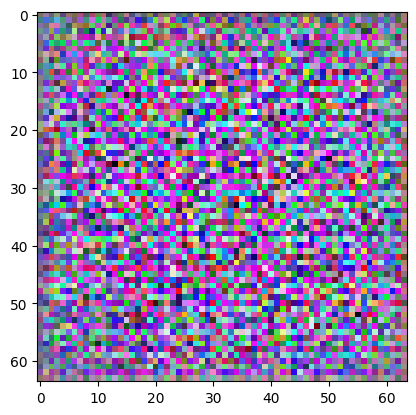

In [43]:
class GenNet(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.conv1 = nn.ConvTranspose2d(100, 512, 4, 1, 0, bias=False)
        self.conv2 = nn.ConvTranspose2d(512, 256, 4, 2, 1, bias=False)
        self.conv3 = nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False)
        self.conv4 = nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False)
        self.conv5 = nn.ConvTranspose2d(64, 3, 4, 2, 1, bias=False)
        
        self.bnorm1 = nn.BatchNorm2d(512)
        self.bnorm2 = nn.BatchNorm2d(256)
        self.bnorm3 = nn.BatchNorm2d(128)
        self.bnorm4 = nn.BatchNorm2d(64)
        
    def forward(self, x_param):
        x_local = F.relu(self.bnorm1(self.conv1(x_param)))
        x_local = F.relu(self.bnorm2(self.conv2(x_local)))
        x_local = F.relu(self.bnorm3(self.conv3(x_local)))
        x_local = F.relu(self.bnorm4(self.conv4(x_local)))
        x_local = torch.tanh(self.conv5(x_local))
        
        return x_local
    
gen_net = GenNet()
y_pred = gen_net(torch.randn(10, 100, 1, 1))

plt.imshow(y_pred[0].detach().numpy().transpose((1, 2, 0)) / 2 + .5)
plt.show()

In [44]:
transform = T.Compose([
    T.ToTensor(),
    T.Resize(64),
    T.Normalize([.5, .5, .5], [.5, .5, .5])
])

dataset = torchvision.datasets.CIFAR10(root='cifar10', download=True, transform=transform)

batch_size   = 32
loader = DataLoader(dataset, batch_size=batch_size, shuffle=True, drop_last=True)

In [45]:
loss_function = nn.BCELoss()

dis_net = DisNet().to(device)
gen_net = GenNet().to(device)

dis_optimizer = torch.optim.Adam(dis_net.parameters(), lr=.0002, betas=(.5, .999))
gen_optimizer = torch.optim.Adam(gen_net.parameters(), lr=.0002, betas=(.5, .999))

In [46]:
epochs_nr = 10

losses = np.zeros((epochs_nr, 2))
dis_decisions = np.zeros((epochs_nr, 2))
real_labels = torch.ones(batch_size, 1).to(device)
fake_labels = torch.zeros(batch_size, 1).to(device)

for epoch in range(epochs_nr):
    batch_losses = np.zeros((len(loader), 2))
    batch_decisions = np.zeros((len(loader), 2))

    for batch_index, (X, _) in enumerate(loader):
        real_images = X.to(device)
        fake_images = gen_net(torch.randn(batch_size, 100, 1, 1).to(device))

        # Train the discriminator
        real_pred = dis_net(real_images)
        real_loss = loss_function(real_pred, real_labels)

        fake_pred = dis_net(fake_images)
        fake_loss = loss_function(fake_pred, fake_labels)

        dis_loss = real_loss + fake_loss
        batch_losses[batch_index, 0] = dis_loss.item()
        batch_decisions[batch_index, 0] = torch.mean((real_pred > .5).float()).item()

        dis_optimizer.zero_grad()
        dis_loss.backward()
        dis_optimizer.step()

        # Train the generator
        fake_images = gen_net(torch.randn(batch_size, 100, 1, 1).to(device))
        fake_pred = dis_net(fake_images)

        gen_loss = loss_function(fake_pred, real_labels)
        batch_losses[batch_index, 1] = gen_loss.item()
        batch_decisions[batch_index, 1] = torch.mean((fake_pred > .5).float()).item()

        gen_optimizer.zero_grad()
        gen_loss.backward()
        gen_optimizer.step()

    losses[epoch, :] = np.mean(batch_losses, axis=0)
    dis_decisions[epoch, :] = np.mean(batch_decisions, axis=0)

    if (epoch + 1) % 5 == 0:
        print(f"Finished epochs {epoch + 1}/{epochs_nr}")

Finished epochs 5/10
Finished epochs 10/10


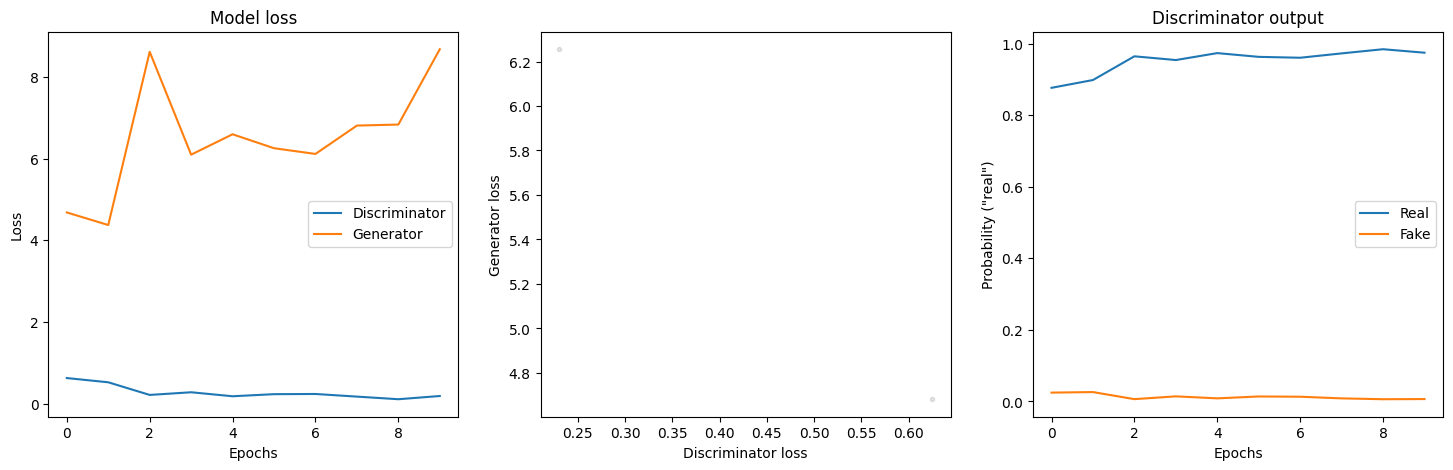

In [47]:
_, ax = plt.subplots(1, 3, figsize=(18, 5))

ax[0].plot(losses[:, 0])
ax[0].plot(losses[:, 1])
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Loss')
ax[0].set_title("Model loss")
ax[0].legend(['Discriminator', 'Generator'])

ax[1].plot(losses[::5, 0], losses[::5, 1], 'k.', alpha=.1)
ax[1].set_xlabel("Discriminator loss")
ax[1].set_ylabel("Generator loss")

ax[2].plot(dis_decisions[:, 0])
ax[2].plot(dis_decisions[:, 1])
ax[2].set_xlabel('Epochs')
ax[2].set_ylabel("Probability (\"real\")")
ax[2].set_title("Discriminator output")
ax[2].legend(['Real', 'Fake'])

plt.show()

In [48]:
gen_net.eval()

fake_images = torch.randn(12, 100, 1, 1).to(device)
generated_images = gen_net(fake_images).cpu()

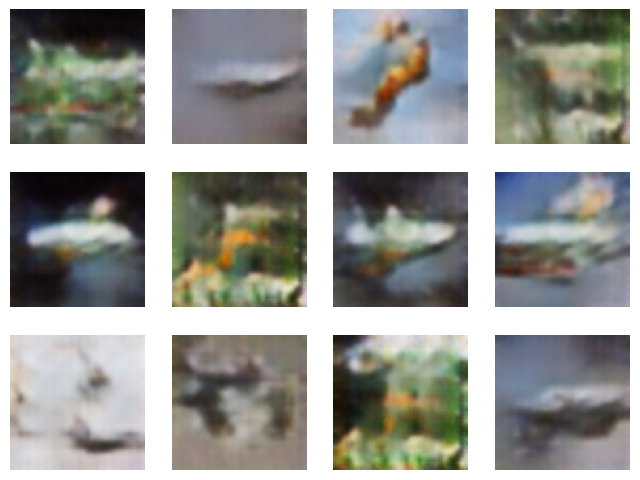

In [49]:
_, axs = plt.subplots(3, 4, figsize=(8, 6))

for i, ax in enumerate(axs.flatten()):
    ax.imshow(generated_images[i, :].detach().numpy().transpose((1, 2, 0)) / 2 + .5)
    ax.axis('off')

plt.show()